# **Lab#4: Implement Keras MLP for Multiclass Classification**
### Dataset: Iris Flower Dataset (via Kaggle)

## What is an MLP?

**MLP** stands for **Multi-Layer Perceptron**. It is simply a neural network that has:
* An **input layer** (the raw features going in),
* One or more **hidden layers** (fully connected "Dense" layers that learn patterns), and
* An **output layer** (that produces the final prediction).

We already built a mini MLP in Practical 3 (4 → 8 → 3) and evaluated it with K-Fold Cross-Validation. In this lab, we build an MLP again for the **same multiclass problem** (predicting 1 of 3 Iris species), but this time we:

* Load the data the way it's structured on **Kaggle**,
* Do a bit of **exploratory data analysis (EDA)**,
* **Scale** the features (a best practice for neural networks),
* Use a **single train/test split** with a **validation set** instead of K-Fold, so we can watch the model learn epoch-by-epoch,
* **Plot** the training curves (loss & accuracy) to see if the model is learning well,
* And finally look at a **confusion matrix** to understand exactly *where* the model gets confused.

### Recap: Why is this "Multiclass" and not "Binary"?
The AND-gate practicals had only **2** possible outputs (0 or 1) — that's **binary classification**.
Here, the Iris dataset has **3** possible outputs (species), so it's **multiclass classification**. This changes two things in our model: the **output layer** (`softmax` with 3 neurons instead of `sigmoid` with 1) and the **loss function** we use.

In [17]:
# 1. Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# numpy / pandas: numerical computation and loading/handling the dataset as a table.
# matplotlib: used to plot the training curves (loss & accuracy over epochs).
# train_test_split: splits data into training and testing portions.
# LabelEncoder: converts text species names into numbers.
# StandardScaler: rescales features so they're all on a similar numeric range.
# confusion_matrix / classification_report: tools to evaluate a multiclass model in detail.
# to_categorical: converts integer labels (0,1,2) into one-hot vectors ([1,0,0], [0,1,0], [0,0,1]).
# Sequential, Dense: same Keras building blocks used in earlier practicals.


## Importing Librarie

### `StandardScaler`
* **Operation:** Normalizes features by subtracting the mean and dividing by the standard deviation:
  $$\hat{x} = \frac{x - \mu}{\sigma}$$
* **Purpose:** Ensures inputs are on a similar scale, improving convergence speed and numerical stability in neural networks (MLPs).

### `to_categorical`
* **Operation:** Converts integer labels into one-hot encoded vectors (e.g., $1 \rightarrow [0, 1, 0]$).
* **Purpose:** Required for `categorical_crossentropy`, which expects target distributions in matrix form $(N, \text{num\_classes})$.
* **Alternative:** `sparse_categorical_crossentropy` works directly with integer labels $(N,)$.

---

##  Data & Layer Mechanics

* **NumPy `ndarray`:** Stored in contiguous memory blocks, enabling vectorized C/CUDA operations. Functions like `np.dot` and batched multiplications in `Dense` layers exploit BLAS libraries for maximum hardware efficiency.
* **Keras/TensorFlow Layers:** Forward passes execute as sequences of tensor matrix multiplications on arrays directly on CPU/GPU, bypassing Python list iteration overhead.

---

## Loss Functions Equivalence

Both `categorical_crossentropy` and `sparse_categorical_crossentropy` evaluate the same cross-entropy formulation:

$$L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$$

Where:
* $C$: Number of target classes
* $y_i$: One-hot encoded true label ($1$ for true class, $0$ otherwise)
* $\hat{y}_i$: Predicted probability for class $i$

Since $y_i = 1$ only for the correct class and $y_i = 0$ for all others, the loss simplifies directly to:

$$L = -\log(\hat{y}_{\text{true class}})$$

### Practical Difference

| Loss Function | Input Expectation | Use Case |
| :--- | :--- | :--- |
| `categorical_crossentropy` | One-hot encoded vectors (via `to_categorical`) | Multi-label targets or soft probability distributions |
| `sparse_categorical_crossentropy` | Integer class labels ($0, 1, 2, \dots$) | Direct class indexing; saves memory by avoiding explicit one-hot matrix creation |

In [18]:
# 2. Load the dataset
import pandas as pd
from sklearn.datasets import load_iris

# Load Iris dataset directly into a pandas DataFrame
iris = load_iris(as_frame=True)

# Extract features and species target
df = iris.frame.copy()
df.rename(columns={"target": "Species"}, inplace=True)

# Map target integer labels back to string class names
species_map = {0: "Iris-setosa", 1: "Iris-versicolor", 2: "Iris-virginica"}
df["Species"] = df["Species"].map(species_map)

# Rename feature columns for consistency
df.columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "Species"]

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [19]:
# 3. A quick look at the data (Exploratory Data Analysis)
print("Shape of dataset:", df.shape)
print("\nColumn info:")
df.info()
print("\nClass distribution:")
print(df["Species"].value_counts())

Shape of dataset: (150, 5)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


# Exploratory Data Analysis

## Data Profiling & Structural Validation

### `df.shape`
* **Operation:** Returns a tuple representing the dimensions of the pandas DataFrame: `(n_samples, n_features + 1)`.
* **Purpose:** Verifies total memory footprint, sample count ($N$), and feature cardinality prior to vectorization.

### `df.info()`
* **Operation:** Performs structural metadata inspection across all columns.
* **Purpose:** 
  * Validates data types (`float64`, `int64`, `object`) to ensure features match required model input interfaces.
  * Identifies missing values (`NaN`/`Null`) to determine whether imputation pipelines or dropped records are necessary before matrix multiplication.

---

## Target Variable & Class Balance Analysis

### `df["Species"].value_counts()`
* **Operation:** Computes absolute frequencies for discrete categorical targets.
* **Distribution Properties:** The Iris dataset exhibits a uniform class distribution:

$$P(Y = c_k) = \frac{1}{K} \quad \forall k \in \{1, \dots, K\}$$

  * $N = 150$ total observations across $K = 3$ distinct target classes ($n_k = 50$ per class).

### Machine Learning Implications
* **Uniform Class Distribution:** A balanced target prior ($P(Y)$) prevents model bias toward a majority class label.
* **Class Imbalance Risks:** In imbalanced datasets, standard loss functions prioritize optimizing overall accuracy ($\frac{TP + TN}{N}$) by heavily predicting the majority class, leading to severe false negative rates ($FN$) on minority classes. Balanced priors allow standard cross-entropy and accuracy metrics to remain informative without requiring synthetic resampling (e.g., SMOTE) or class-weighted loss penalties ($\mathbf{w}_k$).

In [20]:
# 4. Preprocess the data

# Drop the Id column if it exists — it's just a row number, not a useful feature.
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

# Separate features (X) and target (y)
X = df.drop(columns=["Species"]).values.astype(float)
y_text = df["Species"].values

# Encode text labels into integers, then into one-hot vectors
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_text)
y_onehot = to_categorical(y_encoded)

num_classes = y_onehot.shape[1]
print("Classes found:", list(encoder.classes_))
print("Example label before encoding:", y_text[0])
print("Example label after LabelEncoder:", y_encoded[0])
print("Example label after one-hot encoding:", y_onehot[0])

Classes found: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Example label before encoding: Iris-setosa
Example label after LabelEncoder: 0
Example label after one-hot encoding: [1. 0. 0.]


# Target Encoding & Representation Mechanics

## Feature & Target Splitting
* **Identifier Elimination:** Dropping non-predictive variables ($Id \in \mathbb{R}^N$) avoids spurious correlations.
* **Categorical Mapping:** Text labels undergo integer mapping via `LabelEncoder` before being mapped to orthogonal basis vectors using `to_categorical`.

---

## Mathematical Formulation of Encoded Outputs

To train a model emitting class probabilities via Softmax, categorical target vectors $y \in \{0, 1, \dots, K-1\}$ are mapped into a one-hot representation $Y \in \{0, 1\}^{N \times K}$:

$$Y_{ij} = \begin{cases} 1 & \text{if } y_i = j \\ 0 & \text{if } y_i \neq j \end{cases}$$

### Theoretical Justification against Ordinal Encoding
Directly regressing on raw integer targets ($y \in \{0, 1, 2\}$) enforces an arbitrary spatial metric ($d(\text{Class}_0, \text{Class}_2) = 2 \cdot d(\text{Class}_0, \text{Class}_1)$). One-hot encoding creates orthogonal basis vectors in $\mathbb{R}^K$:

$$e_1 = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}, \quad e_2 = \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}, \quad e_3 = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$$

This guarantees equal Euclidean distance between all class pairs ($\|e_i - e_j\|_2 = \sqrt{2} \quad \forall i \neq j$), preventing artificial class ordering assumptions.

### Primary Roles of `LabelEncoder` and the reason of using it


* **Text-to-Numeric Transformation:** Converts non-numeric string labels into discrete integer targets required for mathematical tensor operations:
  $$\text{"Iris-setosa"} \rightarrow 0, \quad \text{"Iris-versicolor"} \rightarrow 1, \quad \text{"Iris-virginica"} \rightarrow 2$$

* **Input Vector Preparation for `to_categorical`:** Provides the continuous integer indexing array required to build one-hot encoded binary matrices[cite: 1]:
  $$0 \rightarrow [1, 0, 0], \quad 1 \rightarrow [0, 1, 0], \quad 2 \rightarrow [0, 0, 1]$$

* **Stratified Sampling:** Enables `train_test_split(..., stratify=y_encoded)` to track and preserve class proportions across training and evaluation splits.

* **Inverse Mapping:** Retains class indices in `encoder.classes_` to map raw numerical predictions back to human-readable strings during post-processing and evaluation.

In [21]:
# 5. Split into training and testing sets, then scale the features
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
# How stratify=y_encoded works:
# 1. Enforces grouped random sampling instead of pure random sampling:
#    - Groups data into class bins first (Setosa, Versicolor, Virginica)[cite: 1].
#    - Applies the split ratio (e.g., 20%) to each bin independently[cite: 1].
#    - Merges the sampled indices back to preserve the exact 1:1:1 class ratio[cite: 1].
# 2. Without stratify, train_test_split uses standard unstratified sampling where
#    each row has an equal independent probability of selection, risking class imbalance bias[cite: 1].

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


# Data Partitioning & Feature Standardization

## Stratified Sampling
* **Stratified Split:** Ensures that class proportions in train ($80\%$) and test ($20\%$) subsets match the target distribution $P(Y)$:
  $$\frac{N_{\text{train}, k}}{N_{\text{train}}} \approx \frac{N_{\text{test}, k}}{N_{\text{test}}} \approx P(Y = c_k)$$

---

## Standardization & Loss Surface Optimization

Features are transformed using the training parameters $(\mu_{\text{train}}, \sigma_{\text{train}})$:

$$z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

### Optimization Impacts
1. **Condition Number Mitigation:** Non-standardized inputs with varying ranges cause ill-conditioned Hessian matrices ($\mathbf{H}$), making the loss surface elliptical. This forces gradient descent into sub-optimal zig-zag trajectories.
2. **Gradient Descent Convergence:** Standardization rescales the loss landscape to be isotropic (spherical), enabling isotropic learning rates to take optimal descent directions.
3. **Data Leakage Prevention:** Parameters $\mu_{\text{train}}$ and $\sigma_{\text{train}}$ are computed solely on the training partition and applied identically to test/validation partitions to prevent data leakage.

In [22]:
# 6. Build the MLP model
model = Sequential([
    Dense(10, input_shape=(X_train.shape[1],), activation='relu'),  # Hidden layer 1
    Dense(8, activation='relu'),                                     # Hidden layer 2
    Dense(num_classes, activation='softmax')                         # Output layer
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

# MLP Architecture & Parameterization Analysis

## Base Architecture & Parameters

| Layer | Type | Input Dim ($n_{\text{in}}$) | Output Dim ($n_{\text{out}}$) | Param Calculation | Total Params | Activation |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Dense 1** | Hidden | 4 | 10 | $(4 \times 10) + 10$ | 50 | `ReLU` |
| **Dense 2** | Hidden | 10 | 8 | $(10 \times 8) + 8$ | 88 | `ReLU` |
| **Dense 3** | Output | 8 | 3 | $(8 \times 3) + 3$ | 27 | `Softmax` |
| **Total** | | | | | **165** | |

$$\text{Parameter Formula: } \text{Params} = (n_{\text{in}} \times n_{\text{out}}) + n_{\text{out}}$$

---

## Architectural Variations & Trade-offs

### 1. Hidden Layer Activations: `ReLU` vs. `Leaky ReLU`
* **`ReLU` ($\max(0, z)$):** Fast and standard. Can suffer from "Dying ReLU" if negative neurons permanently deactivate.
* **`Leaky ReLU` ($\max(\alpha z, z)$):** Keeps a small slope ($\alpha \approx 0.01$) for negative values to prevent dead neurons.
* **On Iris:** Both perform identically due to low dimensionality ($d=4$) and small sample size ($N=150$).

### 2. Output Activation Alternatives

>  **Constraint:** Never use `ReLU`/`Leaky ReLU` on the output layer. Unbounded outputs break probability properties ($\sum \hat{y}_i \neq 1$) and cause $\log(\le 0) \to \text{NaN}$ in cross-entropy loss.

* **`Softmax`:** Outputs normalized probabilities ($\sum \hat{y}_k = 1$). Essential for single-label multiclass prediction.
* **Linear (None):** Outputs raw real-valued logits. Requires `from_logits=True` in Keras loss functions.
* **`Sigmoid`:** Treats each class as an independent binary probability ($\sum \hat{y}_k \neq 1$). Used for multi-label, not single-label multiclass.

---

## 3. Loss Function: `categorical_crossentropy`

Calculates divergence between true one-hot targets ($Y$) and predicted probabilities ($\hat{Y}$):

$$L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$$

* **Why not MSE?** Pairing MSE with Softmax creates a non-convex loss surface with flat plateaus (vanishing gradients). Cross-entropy yields error-proportional gradients $(\hat{y}_i - y_i)$, driving faster updates.

---

## 4. Optimization Mechanics

* **`SGD`:** Standard updates along mini-batch gradients. Slow convergence; sensitive to learning rate.
* **`SGD + Momentum`:** Uses velocity terms to smooth out oscillations and accelerate convergence.
* **`RMSprop`:** Uses adaptive per-parameter learning rates based on recent squared gradients.
* **`Adam` (Default):** Combines Momentum + RMSprop. Best balance of adaptive scaling, stability, and speed.

---

## Quick Reference Summary

| Hyperparameter | Choice | Reason / Impact |
| :--- | :--- | :--- |
| **Hidden Activation** | `ReLU` / `Leaky ReLU` | Both work well; `Leaky ReLU` protects against dead neurons. |
| **Output Activation** | `Softmax` | Guarantees valid probability outputs over $K$ classes. |
| **Loss Function** | `categorical_crossentropy` | Mathematically optimal for one-hot encoded multi-class targets. |
| **Optimizer** | `Adam` | Fast, adaptive convergence without heavy manual tuning. |

In [23]:
# 7. Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    verbose=1 # Shows progress bar + loss/metrics output per epoch
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3229 - loss: 1.1080 - val_accuracy: 0.3333 - val_loss: 1.0367
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3229 - loss: 1.0549 - val_accuracy: 0.4167 - val_loss: 0.9892
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3438 - loss: 1.0047 - val_accuracy: 0.4583 - val_loss: 0.9439
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3958 - loss: 0.9587 - val_accuracy: 0.5000 - val_loss: 0.9036
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4375 - loss: 0.9169 - val_accuracy: 0.6250 - val_loss: 0.8651
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4792 - loss: 0.8793 - val_accuracy: 0.7083 - val_loss: 0.8295
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 0.8430 - val_accuracy: 0.7917 - val_loss: 0.7982
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5625 - loss: 0.8109 - val_accuracy: 0.9167 - 

# Training Mechanics & Backpropagation Dynamics

## Training Parameters
* **Validation Split ($20\%$):** Evaluates out-of-sample performance after each epoch to monitor generalization gap.
* **Batch Size ($B = 8$):** Controls Mini-Batch Stochastic Gradient Descent (MSGD) update frequency per epoch.
* **Epoch Count ($100$):** Total full forward/backward passes through the training partition.

---

## Backpropagation & Optimization

1. **Forward Pass:** Input matrices compute activation outputs through hidden layers up to predicted vectors $\hat{Y}$.
2. **Loss Evaluation:** Categorical Cross-Entropy measures deviation from one-hot target targets:
   $$L(\theta) = -\frac{1}{B} \sum_{i=1}^{B} \sum_{k=1}^{K} Y_{i,k} \log(\hat{Y}_{i,k})$$
3. **Gradient Calculation:** Errors propagate backward using the chain rule to compute parameter gradients $\frac{\partial L}{\partial W^{[l]}}$ and $\frac{\partial L}{\partial b^{[l]}}$.
4. **Adam Optimization:** Parameters are updated using adaptive first ($m_t$) and second moment ($v_t$) gradient estimators:
   $$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

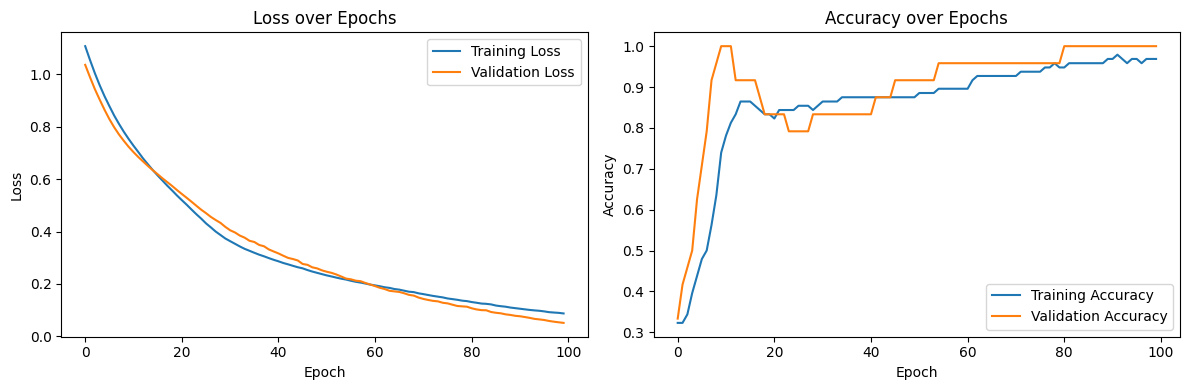

In [24]:
# 8. Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# Convergence Analysis & Diagnostic Optimization

## Diagnostics via Loss/Accuracy Trajectories

* **Ideal Convergence:** Training and validation losses decrease asymptotically while metric accuracies increase toward stability.
* **Underfitting (High Bias):** Loss trajectories flatten early at high values.
  * *Mitigation:* Increase model capacity (add layers/units) or reduce regularization constraints.
* **Overfitting (High Variance):** Training loss continually decreases while validation loss diverges upward.
  * *Mitigation:* Apply $L_1/L_2$ weight regularization, introduce `Dropout` layers, or implement `EarlyStopping`.

---

## Bias-Variance Tradeoff Metrics

| Trajectory Pattern | Structural Indication | Recommended Remedial Actions |
| :--- | :--- | :--- |
| $L_{\text{train}} \gg 0$, $L_{\text{val}} \gg 0$ | High Bias (Underfitting) | Increase parameter capacity, train longer |
| $L_{\text{train}} \to 0$, $L_{\text{val}} \uparrow$ | High Variance (Overfitting) | Dropout, $L_2$ Regularization, Early Stopping |
| $L_{\text{train}} \approx L_{\text{val}} \to \text{Min}$ | Optimal Generalization | Retain current model parameterization |

In [25]:
# 9. Evaluate on the unseen test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.1218
Test Accuracy: 93.33%


# Test Set Evaluation

## Unbiased Generalization Assessment
Computes cross-entropy loss and multi-class accuracy on held-out test data $(X_{\text{test}}, Y_{\text{test}})$ to evaluate generalization without train/validation hyperparameter tuning bias.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


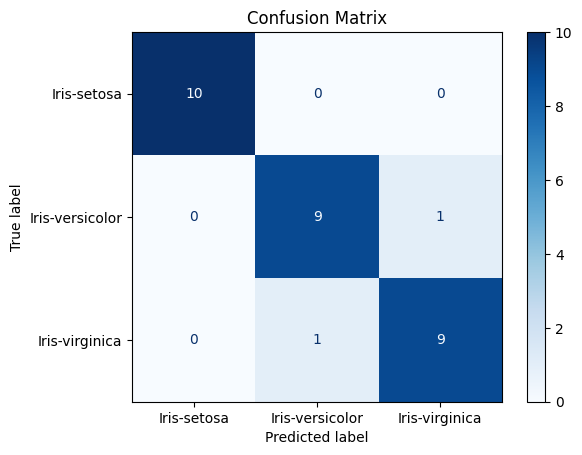


Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



In [26]:
# 10. Confusion Matrix and detailed classification report
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

# Multi-class Performance Metrics & Confusion Analysis

## Prediction Processing
Continuous probabilities are mapped to discrete class assignments via argmax over class dimensions:

$$\hat{y}_i = \arg\max_{k \in \{1, \dots, K\}} \hat{Y}_{i, k}$$

---

## Diagnostic Metrics Metrics

### Classification Metrics (Per-Class $k$)

* **Precision:** Ratio of true class predictions relative to total class positive predictions:
  $$\text{Precision}_k = \frac{TP_k}{TP_k + FP_k}$$

* **Recall:** Ratio of true class predictions relative to actual true instances:
  $$\text{Recall}_k = \frac{TP_k}{TP_k + FN_k}$$

* **$F_1$-Score:** Harmonic mean balancing per-class Precision and Recall:
  $$F_{1, k} = 2 \cdot \frac{\text{Precision}_k \cdot \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}$$

---

## Error Analysis Analysis
* **Setosa Separation:** Non-overlapping feature margins ensure near-perfect linearly separable boundary performance.
* **Versicolor vs. Virginica:** Class overlaps in feature space lead to off-diagonal confusion matrix values ($FP/FN$), highlighting irreducible data noise at class boundaries.

# Summary & Pipeline Overview

## Architecture & Workflow Summary
1. **Preprocessing Pipeline:** Feature standardization via `StandardScaler` combined with target one-hot encoding using `to_categorical`.
2. **Model Design:** Feedforward architecture ($4 \rightarrow 10 \rightarrow 8 \rightarrow 3$) utilizing Softmax outputs matched with Categorical Cross-Entropy loss.
3. **Training Strategy:** Mini-batch optimization with internal cross-validation monitoring to prevent overfitting.
4. **Performance Evaluation:** Combined confusion matrices and per-class $F_1$-scores to assess boundary performance on overlapping classes (`Iris-versicolor` vs. `Iris-virginica`).